This notebook focuses on predicting branch revenue using time-aware features to avoid data leakage.

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
branch = pd.read_csv(r"C:\Users\AZER\Downloads\export.csv")
order = pd.read_csv(r"C:\Users\AZER\Downloads\export (3).csv")
order_details = pd.read_csv(r"C:\Users\AZER\Downloads\export (4).csv")

In [33]:
branch_order = order.merge(branch,on = 'BRANCH_ID')

In [34]:
orders_simple = order_details.merge(branch_order, on='ORDER_ID')

In [35]:
orders_simple.head()

,DETAIL_ID,ORDER_ID,ITEM_ID,QUANTITY,UNIT_PRICE,TOTAL_PRICE,CUSTOMER_ID,BRANCH_ID,ORDER_DATE,ORDER_HOUR,ORDER_TYPE,PAYMENT_METHOD,RATING,STATUS,BRANCH_NAME,CITY,DISTRICT,BRANCH_TYPE,SEATING_CAPACITY,OPEN_DATE
0,1,1,32,2,5,10,220,1,2024-08-05T00:00:00Z,11,Dine-in,Online,4.3,Completed,Lezzetli Fountain Square,Baki,Nasimi,Dine-in,120,2020-03-15T00:00:00Z
1,2,1,9,1,15,15,220,1,2024-08-05T00:00:00Z,11,Dine-in,Online,4.3,Completed,Lezzetli Fountain Square,Baki,Nasimi,Dine-in,120,2020-03-15T00:00:00Z
2,3,1,27,1,6,6,220,1,2024-08-05T00:00:00Z,11,Dine-in,Online,4.3,Completed,Lezzetli Fountain Square,Baki,Nasimi,Dine-in,120,2020-03-15T00:00:00Z
3,4,1,3,1,16,16,220,1,2024-08-05T00:00:00Z,11,Dine-in,Online,4.3,Completed,Lezzetli Fountain Square,Baki,Nasimi,Dine-in,120,2020-03-15T00:00:00Z
4,5,2,32,1,5,5,315,1,2024-06-17T00:00:00Z,20,Dine-in,Card,4.1,Completed,Lezzetli Fountain Square,Baki,Nasimi,Dine-in,120,2020-03-15T00:00:00Z


In [36]:
from datetime import datetime
orders_simple['ORDER_DATE'] = pd.to_datetime(orders_simple['ORDER_DATE'])
orders_simple['Hour'] = pd.to_datetime(orders_simple['ORDER_HOUR']).dt.hour
orders_simple['day_of_week'] = pd.to_datetime(orders_simple['ORDER_DATE']).dt.day_of_week


In [37]:
print(orders_simple.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   DETAIL_ID         1000 non-null   int64              
 1   ORDER_ID          1000 non-null   int64              
 2   ITEM_ID           1000 non-null   int64              
 3   QUANTITY          1000 non-null   int64              
 4   UNIT_PRICE        1000 non-null   int64              
 5   TOTAL_PRICE       1000 non-null   int64              
 6   CUSTOMER_ID       1000 non-null   int64              
 7   BRANCH_ID         1000 non-null   int64              
 8   ORDER_DATE        1000 non-null   datetime64[us, UTC]
 9   ORDER_HOUR        1000 non-null   int64              
 10  ORDER_TYPE        1000 non-null   str                
 11  PAYMENT_METHOD    1000 non-null   str                
 12  RATING            878 non-null    float64            
 13  STATUS         

Bura qədər elədiyimiz data yüklənməsi və columnların tipini dətişdirmək üçün elədiyiniz addımlar idi

In [57]:
orders_simple['target'] = (orders_simple['RATING']).apply(pd.to_numeric,errors ='coerce').fillna(0).astype(int)
orders_simple['target'] = (orders_simple['RATING'] >= 4)

In [40]:
train = orders_simple[orders_simple['ORDER_DATE']<='2023-11-01']
test = orders_simple[orders_simple['ORDER_DATE']>'2023-11-01']

In [ ]:

features = ['TOTAL_PRICE', 'QUANTITY', 'Hour', 'day_of_week','CITY']


X_train_raw = train[features]
X_test_raw  = test[features]


X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_test  = pd.get_dummies(X_test_raw, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


y_train = train['target']
y_test  = test['target']

In [63]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
num_cols = ['TOTAL_PRICE', 'QUANTITY', 'Hour', 'day_of_week']
train[num_cols] = ss.fit_transform(X_train[num_cols])
test[num_cols] = ss.fit_transform(X_test[num_cols])

Burda biz datanı 2 yerə bölürük train və test hissəsinə bölürük. Daha sonra isə encoding edərək datanı boolean tiplərə çeviririk. Üçüncü addımda isə scaling edərək outlier yəni ədədi ortadan çox böyük olan dəyərləri ədədi ortaya yaxın edir

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.5822147651006712


Burda artıq modelimizi train edirik və nəticədə dəqiqlik 58%dir

In [61]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[  0   0   0   0  64   0]
 [  0   0   0   0  10   0]
 [  0   0   0   0  34   0]
 [  0   0   0   0 113   0]
 [  0   0   0   0 351   0]
 [  0   0   0   0  24   0]]


In [65]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        64
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00        34
           3       0.00      0.00      0.00       113
           4       0.59      0.99      0.74       351
           5       0.00      0.00      0.00        24

    accuracy                           0.58       596
   macro avg       0.10      0.16      0.12       596
weighted avg       0.35      0.58      0.43       596



c:\Users\AZER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AZER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AZER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

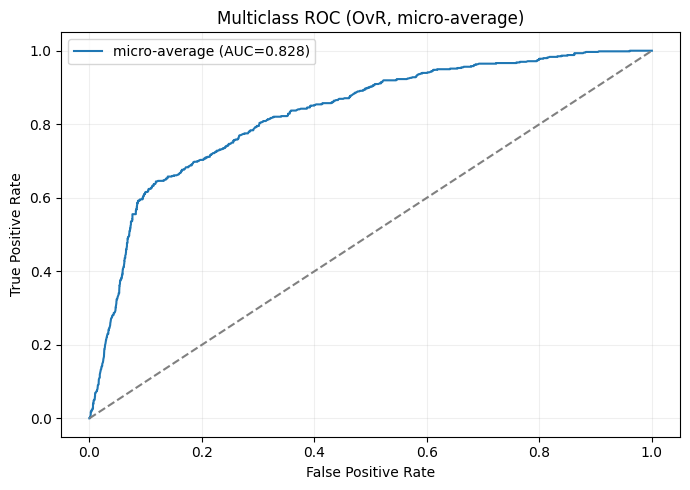

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)          
y_score = model.predict_proba(X_test)                         


fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
auc_micro = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")

plt.figure(figsize=(7,5))
plt.plot(fpr_micro, tpr_micro, label=f"micro-average (AUC={auc_micro:.3f})")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (OvR, micro-average)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Burda biz modelimizin nece öyrəndiyi barədə qrafik göstəririk.Qrafikdən görsənirki modelimiz 82  dəqiqiliklə öyrənilib